In [17]:
import os
print(os.getcwd())

/workspace/skoltech/tsfm-2026


In [9]:
import os
os.chdir("/workspace/skoltech/tsfm-2026")

In [28]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter

data_dir = Path("TSB-AD-U")

dataset_counter = Counter()

for csv_path in data_dir.glob("*.csv"):
    
    parts = csv_path.stem.split("_")
    
    # нужная часть имени
    new_stem = "_".join(parts[:4])
    
    dataset_name = parts[1]
    dataset_counter[dataset_name] += 1
    
    new_path = csv_path.with_name(new_stem + ".csv")
    
    csv_path.rename(new_path)

print("Файлов в каждом датасете:")
for dataset, count in dataset_counter.items():
    print(f"{dataset}: {count}")

Файлов в каждом датасете:
YAHOO: 259
UCR: 228
SVDB: 20
WSD: 111
MITDB: 8
SMD: 38
Daphnet: 1
LTDB: 9
Exathlon: 32
OPPORTUNITY: 29
NAB: 28
SMAP: 19
IOPS: 17
MSL: 9
Stock: 20
MGAB: 9
Power: 1
NEK: 9
TODS: 15
SED: 3
SWaT: 1
TAO: 3
CATSv2: 1


In [35]:
import pandas as pd
import numpy as np
from pathlib import Path

data_dir = Path("Datasets/TSB-AD-U")

rows_meta = []

for csv_path in data_dir.glob("*.csv"):
    
    df = pd.read_csv(csv_path)
    labels = df["Label"].values
    
    # есть ли подряд идущие аномалии
    has_sequential = np.any((labels[:-1] == 1) & (labels[1:] == 1))
    
    rows_meta.append({
        "file": csv_path.stem,
        "has_sequential_anomaly": has_sequential
    })

meta_df = pd.DataFrame(rows_meta)

print(meta_df.head())
print()
print("Количество файлов с sequential аномалиями:")
print(meta_df["has_sequential_anomaly"].value_counts())

                                         file  has_sequential_anomaly
0  808_YAHOO_id_258_WebService_tr_500_1st_142                    True
1   784_YAHOO_id_234_Synthetic_tr_500_1st_623                    True
2   435_UCR_id_133_Medical_tr_14750_1st_47830                    True
3  250_SVDB_id_14_Medical_tr_50000_1st_107354                    True
4   248_SVDB_id_12_Medical_tr_18462_1st_18562                    True

Количество файлов с sequential аномалиями:
has_sequential_anomaly
True     696
False    174
Name: count, dtype: int64


In [36]:
meta_df

,file,has_sequential_anomaly
0,808_YAHOO_id_258_WebService_tr_500_1st_142,True
1,784_YAHOO_id_234_Synthetic_tr_500_1st_623,True
2,435_UCR_id_133_Medical_tr_14750_1st_47830,True
3,250_SVDB_id_14_Medical_tr_50000_1st_107354,True
4,248_SVDB_id_12_Medical_tr_18462_1st_18562,True
...,...,...
865,423_UCR_id_121_Facility_tr_13750_1st_52600,True
866,086_WSD_id_58_WebService_tr_4436_1st_9529,True
867,117_WSD_id_89_WebService_tr_3251_1st_3351,True
868,171_MITDB_id_2_Medical_tr_50000_1st_88864,True


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

data_dir = Path("Datasets/TSB-AD-U")

rows_meta = []

for csv_path in data_dir.glob("*.csv"):
    
    df = pd.read_csv(csv_path)
    labels = df["Label"].values
    
    has_sequential = np.any((labels[:-1] == 1) & (labels[1:] == 1))
    
    rows_meta.append({
        "file": csv_path.name,   # ← имя с расширением
        "has_sequential_anomaly": has_sequential
    })

meta_df = pd.DataFrame(rows_meta)

# выбираем только файлы без последовательных аномалий
no_seq_files = meta_df.loc[
    meta_df["has_sequential_anomaly"] == False,
    "file"
]

# сохраняем
no_seq_files.to_frame(name="file").to_csv(
    "no_seq_anomaly_files.csv",
    index=False
)

print("Сохранено файлов:", len(no_seq_files))

Сохранено файлов: 174


In [6]:
meta_df[meta_df["has_sequential_anomaly"] == False]

,file,has_sequential_anomaly
1,637_YAHOO_id_87,False
5,645_YAHOO_id_95,False
8,623_YAHOO_id_73,False
27,608_YAHOO_id_58,False
31,771_YAHOO_id_221,False
...,...,...
850,799_YAHOO_id_249,False
855,638_YAHOO_id_88,False
858,595_YAHOO_id_45,False
862,721_YAHOO_id_171,False


In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
import shutil
from collections import Counter

data_dir = Path("TSB-AD-U")
out_dir =  Path("no_seq_anomaly")
out_dir.mkdir(exist_ok=True)

dataset_counter = Counter()

for csv_path in data_dir.glob("*.csv"):
    
    df = pd.read_csv(csv_path)
    labels = df["Label"].values
    
    # проверка на подряд идущие аномалии
    has_sequential = np.any((labels[:-1] == 1) & (labels[1:] == 1))
    
    if not has_sequential:
        shutil.copy(csv_path, out_dir / csv_path.name)
        
        dataset_name = csv_path.stem.split("_")[1]
        dataset_counter[dataset_name] += 1

print("Статистика файлов без sequential аномалий:\n")

total = 0
for dataset, count in sorted(dataset_counter.items()):
    print(f"{dataset}: {count}")
    total += count

print("\nВсего файлов:", total)

Статистика файлов без sequential аномалий:

UCR: 10
YAHOO: 164

Всего файлов: 174


In [3]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

data_dir = Path("no_seq_anomaly")

rows = []

for csv_path in data_dir.glob("*.csv"):
    df = pd.read_csv(csv_path)

    length = len(df)
    anomaly_count = df["Label"].sum()
    anomaly_ratio = anomaly_count / length

    rows.append({
        "file": csv_path.stem,
        "length": length,
        "anomaly_count": anomaly_count,
        "anomaly_ratio": anomaly_ratio
    })

meta_df = pd.DataFrame(rows)

print("Статистика длин рядов\n")
print(meta_df["length"].describe())

print("\nСтатистика количества аномалий\n")
print(meta_df["anomaly_count"].describe())

print("\nСтатистика доли аномалий\n")
print(meta_df["anomaly_ratio"].describe())

print("\nРяды с наименьшим числом аномалий:")
print(meta_df.nsmallest(5, "anomaly_count")[["file", "anomaly_count"]])

print("\nРяды с наибольшим числом аномалий:")
print(meta_df.nlargest(5, "anomaly_count")[["file", "anomaly_count"]])

Статистика длин рядов

count     164.000000
mean     1631.189024
std       101.423764
min      1420.000000
25%      1680.000000
50%      1680.000000
75%      1680.000000
max      1680.000000
Name: length, dtype: float64

Статистика количества аномалий

count    164.000000
mean       6.841463
std        5.194309
min        1.000000
25%        2.000000
50%        6.000000
75%       12.000000
max       16.000000
Name: anomaly_count, dtype: float64

Статистика доли аномалий

count    164.000000
mean       0.004094
std        0.003068
min        0.000595
25%        0.001190
50%        0.003571
75%        0.007143
max        0.009524
Name: anomaly_ratio, dtype: float64

Ряды с наименьшим числом аномалий:
                file  anomaly_count
1    645_YAHOO_id_95              1
10   624_YAHOO_id_74              1
14  689_YAHOO_id_139              1
23  673_YAHOO_id_123              1
25   605_YAHOO_id_55              1

Ряды с наибольшим числом аномалий:
                file  anomaly_count
4   

In [4]:
meta_df

,file,length,anomaly_count,anomaly_ratio
0,637_YAHOO_id_87,1680,7,0.004167
1,645_YAHOO_id_95,1680,1,0.000595
2,623_YAHOO_id_73,1680,15,0.008929
3,608_YAHOO_id_58,1680,14,0.008333
4,771_YAHOO_id_221,1680,16,0.009524
...,...,...,...,...
159,799_YAHOO_id_249,1680,6,0.003571
160,638_YAHOO_id_88,1421,1,0.000704
161,595_YAHOO_id_45,1680,6,0.003571
162,721_YAHOO_id_171,1421,1,0.000704


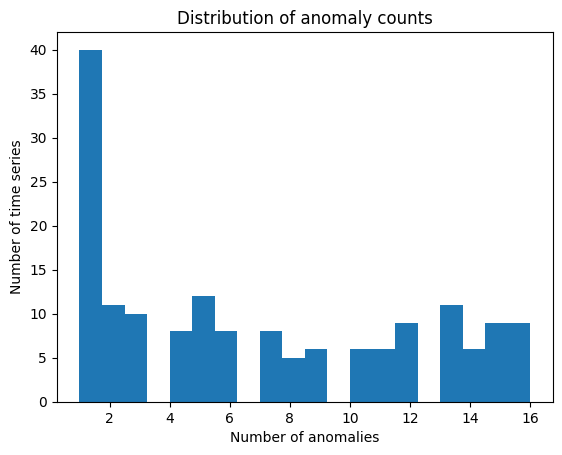

In [5]:
plt.hist(meta_df["anomaly_count"], bins=20)
plt.xlabel("Number of anomalies")
plt.ylabel("Number of time series")
plt.title("Distribution of anomaly counts")
plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("no_seq_anomaly")

def plot_series(csv_path):
    df = pd.read_csv(csv_path)

    plt.figure(figsize=(12,3))
    plt.plot(df["Data"], color="gray")
    plt.scatter(
        df.index[df["Label"] == 1],
        df["Data"][df["Label"] == 1],
        color="red",
        s=15
    )
    plt.title(csv_path.name)
    plt.show()


In [ ]:
import numpy as np

files = list(data_dir.glob("*.csv"))
sample = np.random.choice(files, size=min(20, len(files)), replace=False)

for f in sample:
    plot_series(f)

array([], dtype=float64)

выбрать датасет с коллективными аномалиями

In [33]:
import pandas as pd
import numpy as np
from pathlib import Path

data_dir = Path("TSB-AD-U")

rows_meta = []

for csv_path in data_dir.glob("*.csv"):
    
    df = pd.read_csv(csv_path)
    labels = df["Label"].values
    
    has_sequential = np.any((labels[:-1] == 1) & (labels[1:] == 1))
    
    rows_meta.append({
        "file": csv_path.name,   # ← имя с расширением
        "has_sequential_anomaly": has_sequential
    })

meta_df = pd.DataFrame(rows_meta)

# выбираем только файлы без последовательных аномалий
with_seq_files = meta_df.loc[
    (meta_df["has_sequential_anomaly"] == True) &
    (meta_df["file"].str.contains("UCR", na=False)),
    "file"
]

# сохраняем
with_seq_files.to_frame(name="file").to_csv(
    "with_seq_anomaly_files.csv",
    index=False
)

print("Сохранено файлов:", len(with_seq_files))

Сохранено файлов: 218


In [34]:
meta_df

,file,has_sequential_anomaly
0,808_YAHOO_id_258_WebService_tr_500_1st_142.csv,True
1,784_YAHOO_id_234_Synthetic_tr_500_1st_623.csv,True
2,435_UCR_id_133_Medical_tr_14750_1st_47830.csv,True
3,250_SVDB_id_14_Medical_tr_50000_1st_107354.csv,True
4,248_SVDB_id_12_Medical_tr_18462_1st_18562.csv,True
...,...,...
865,423_UCR_id_121_Facility_tr_13750_1st_52600.csv,True
866,086_WSD_id_58_WebService_tr_4436_1st_9529.csv,True
867,117_WSD_id_89_WebService_tr_3251_1st_3351.csv,True
868,171_MITDB_id_2_Medical_tr_50000_1st_88864.csv,True


In [20]:
from pathlib import Path
import shutil

data_dir = Path("Datasets/TSB-AD-U")
out_dir = Path("Datasets/with_seq_anomaly")
out_dir.mkdir(exist_ok=True)

for file_name in with_seq_files:
    src = data_dir / file_name
    dst = out_dir / file_name
    
    if src.exists():
        shutil.move(str(src), str(dst))
    else:
        print(f"Файл не найден: {src}")

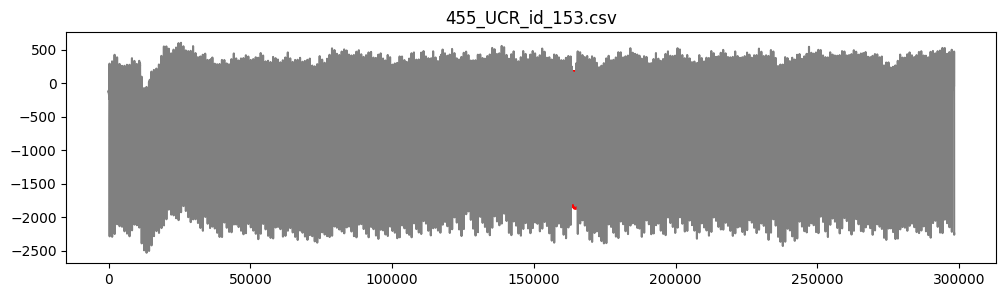

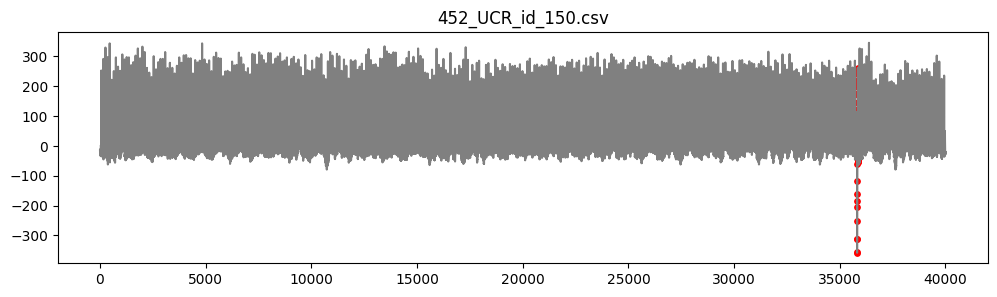

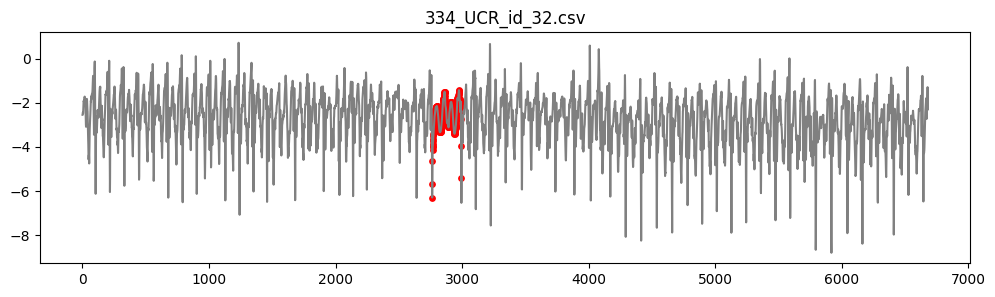

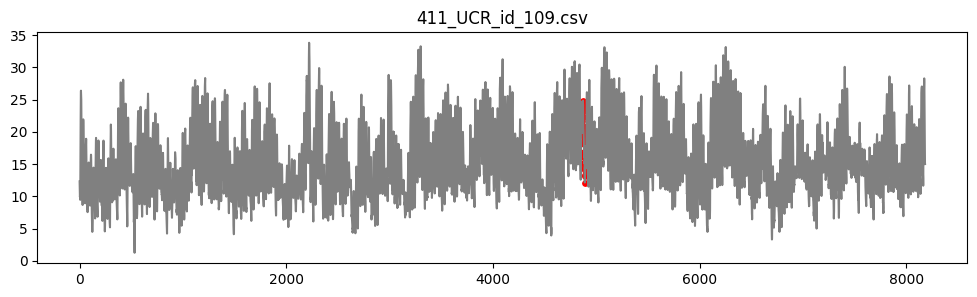

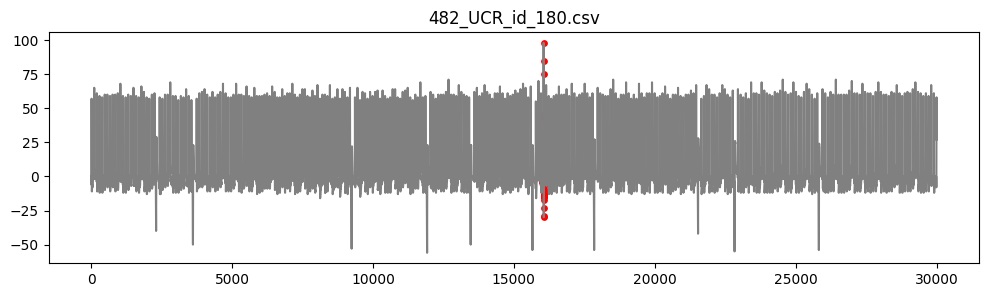

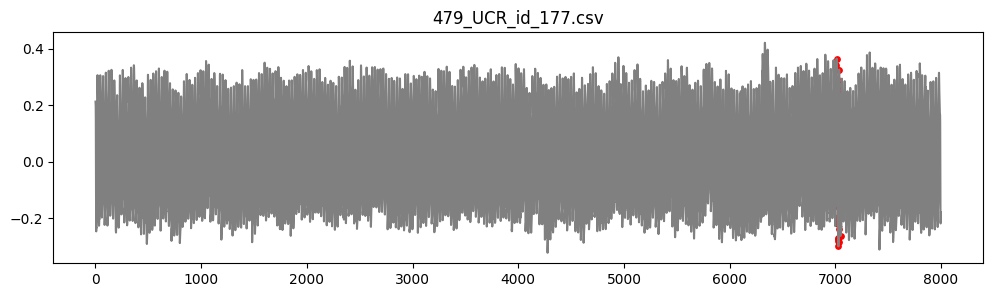

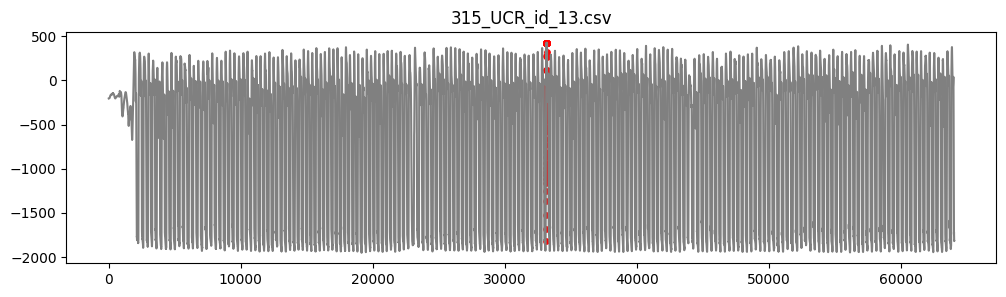

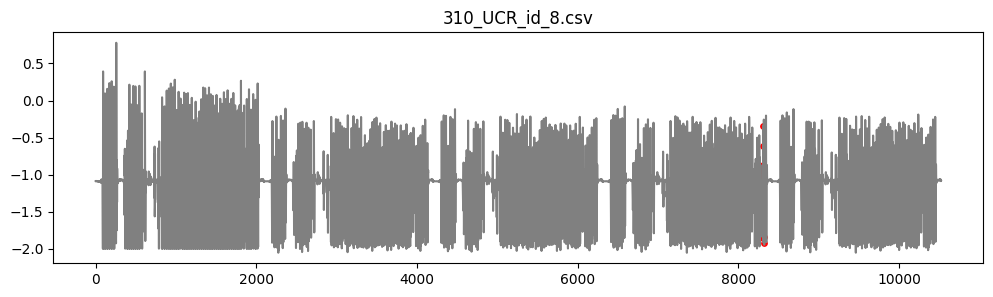

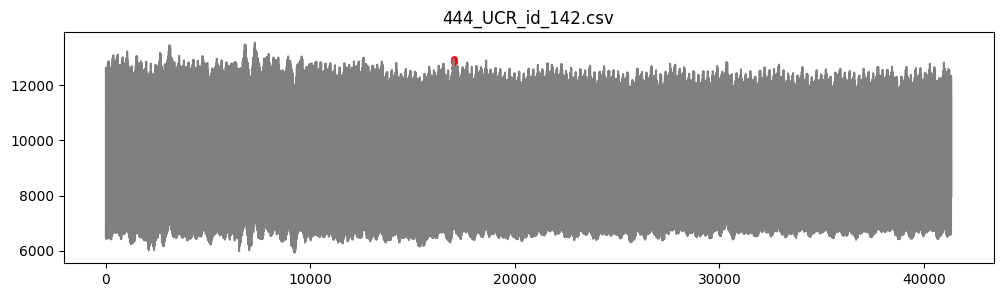

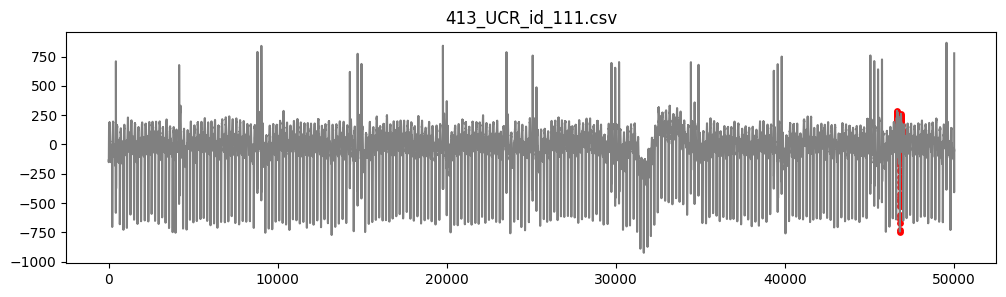

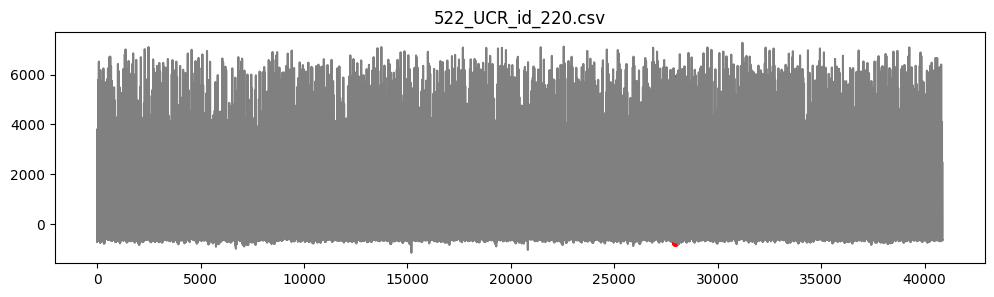

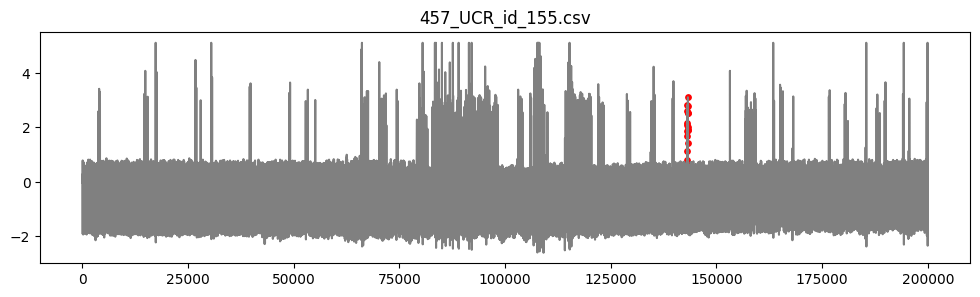

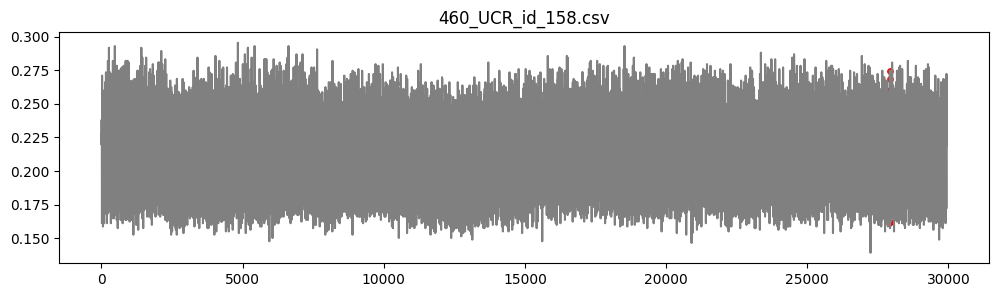

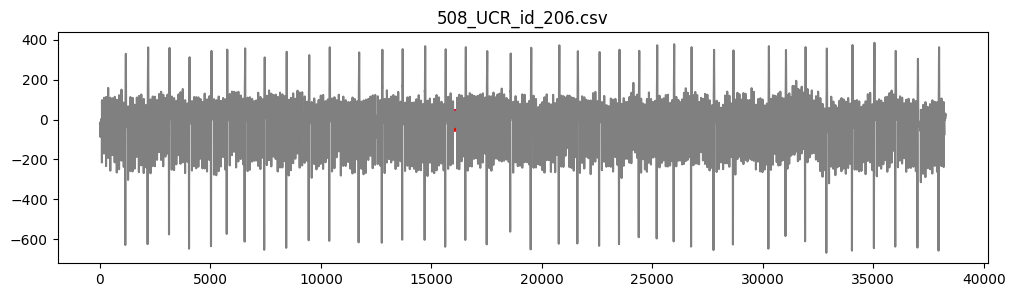

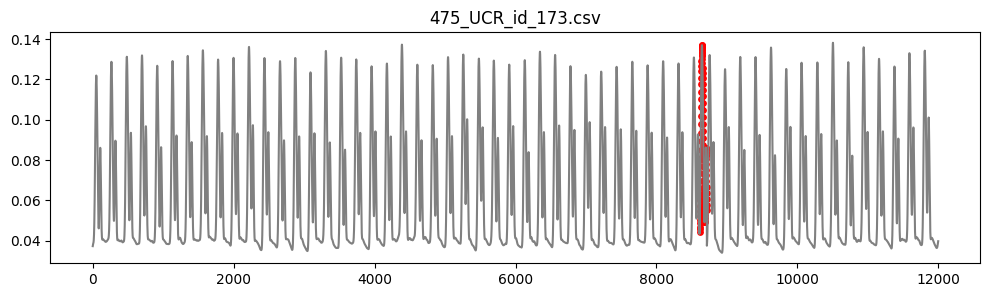

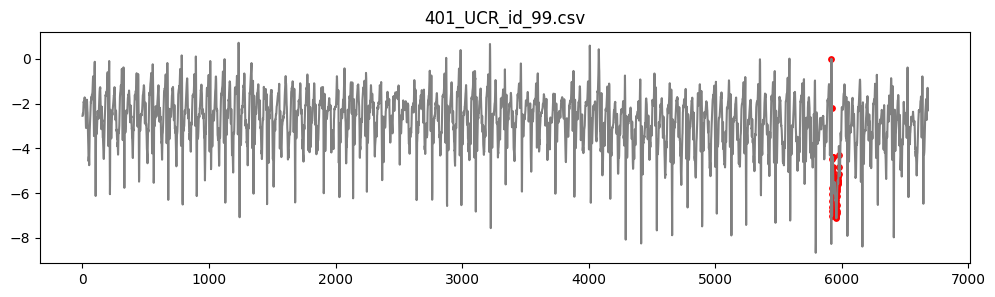

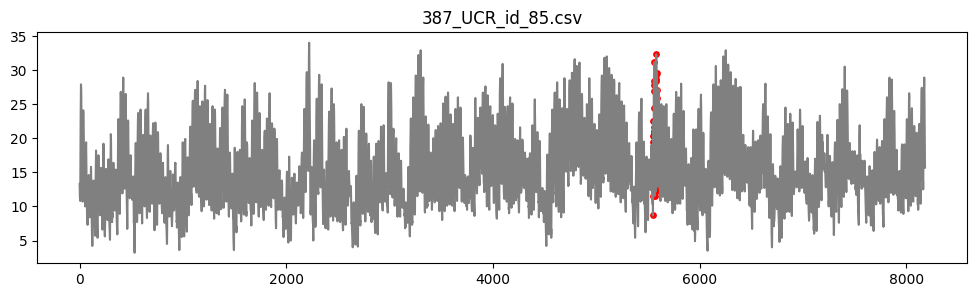

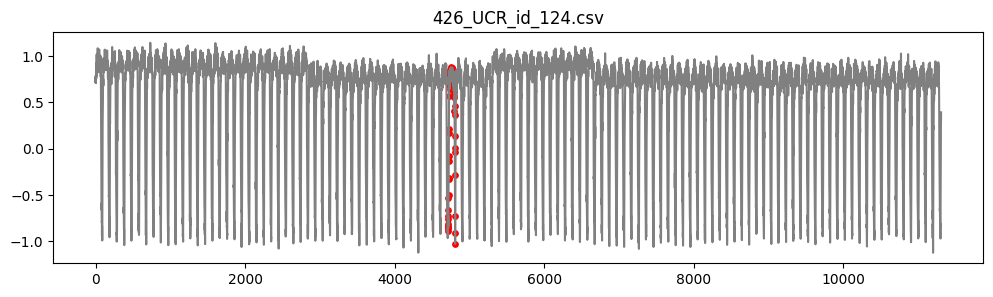

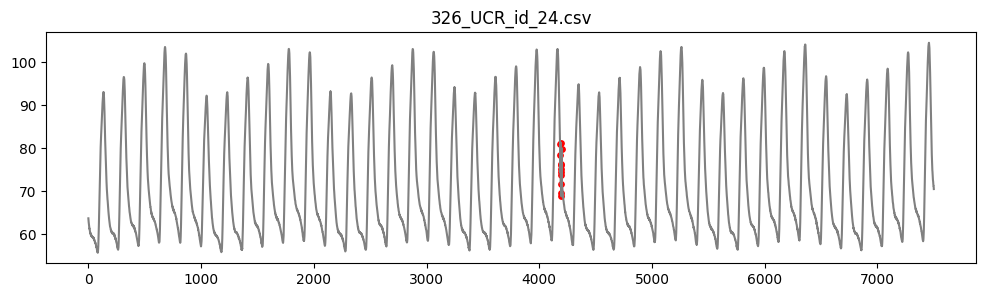

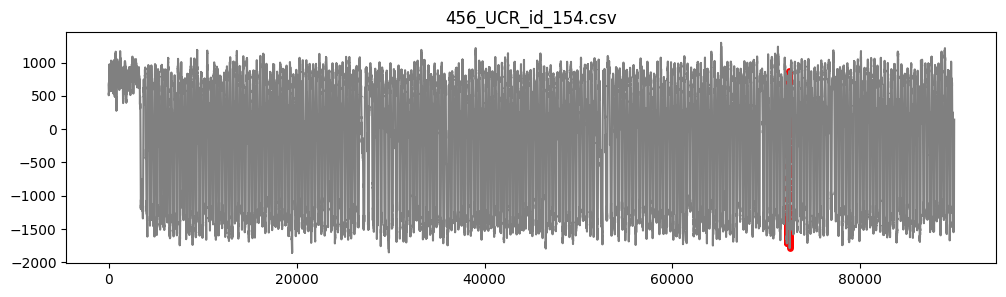

In [22]:
import numpy as np


data_dir = Path("Datasets/with_seq_anomaly")
files = list(data_dir.glob("*.csv"))
sample = np.random.choice(files, size=min(20, len(files)), replace=False)

for f in sample:
    plot_series(f)

мультивариат ряд

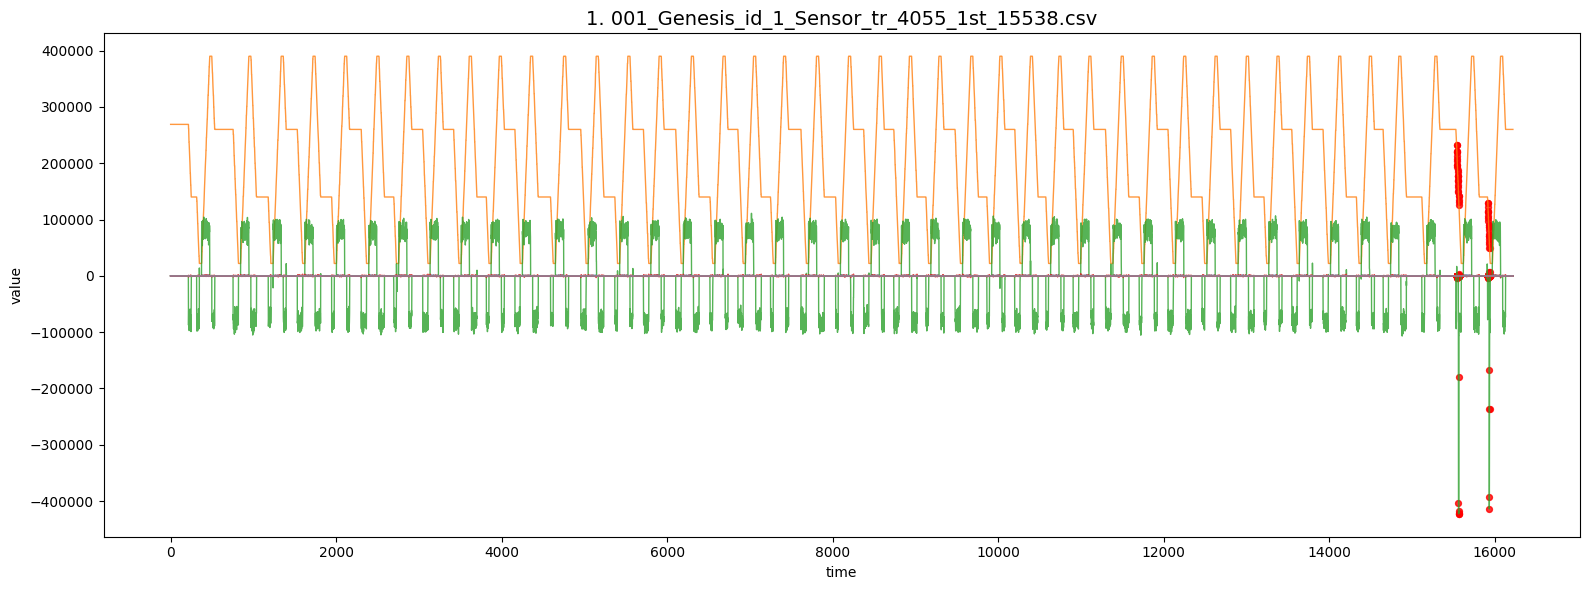

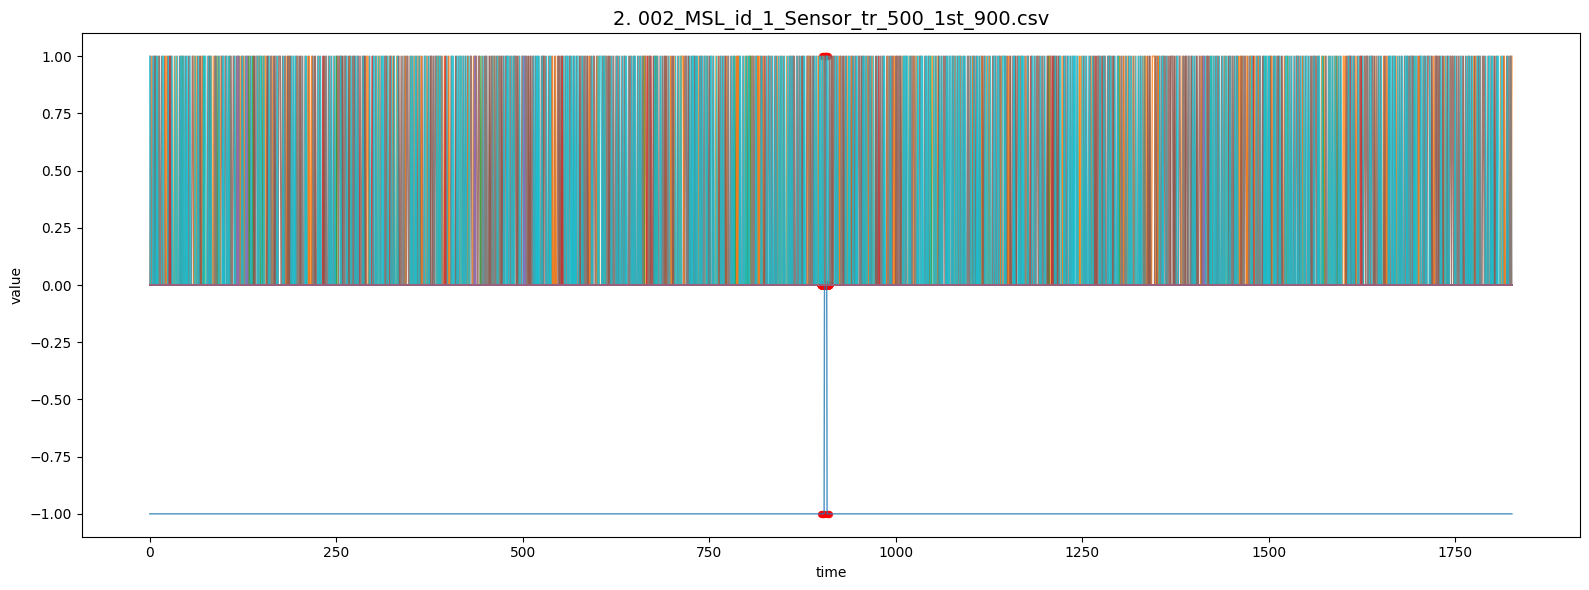

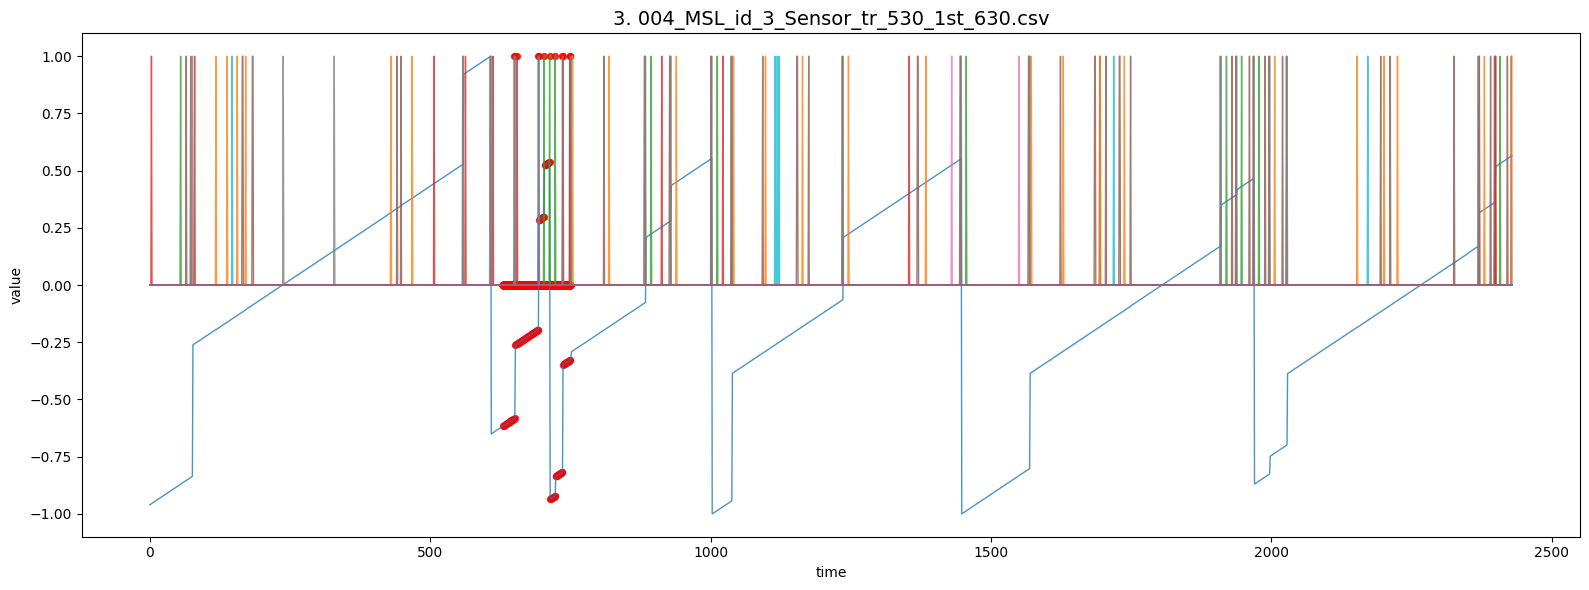

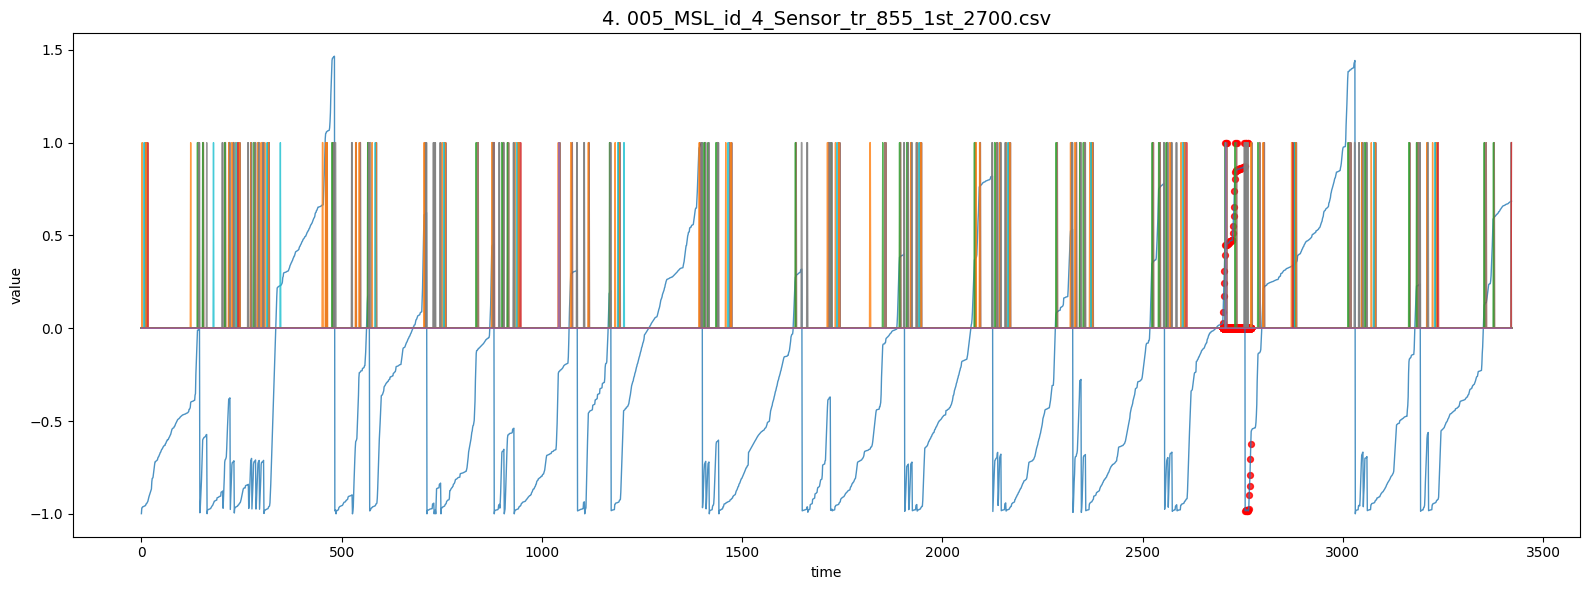

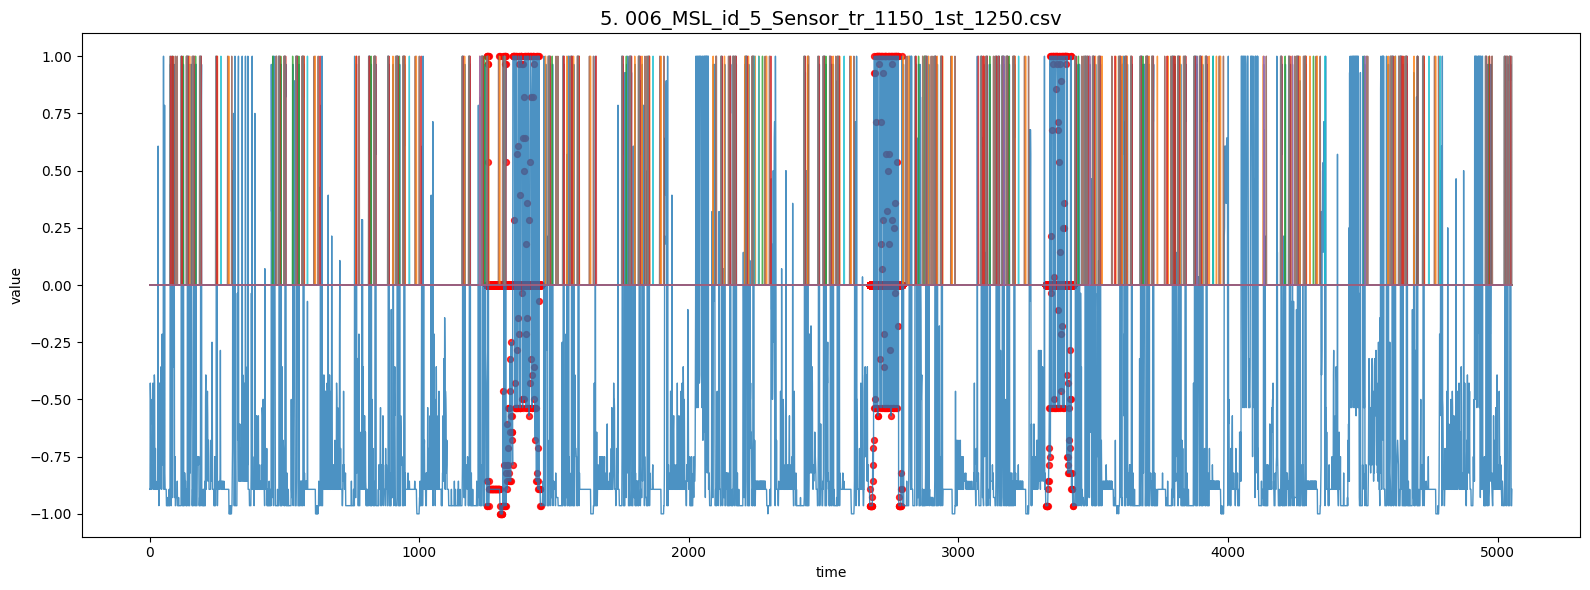

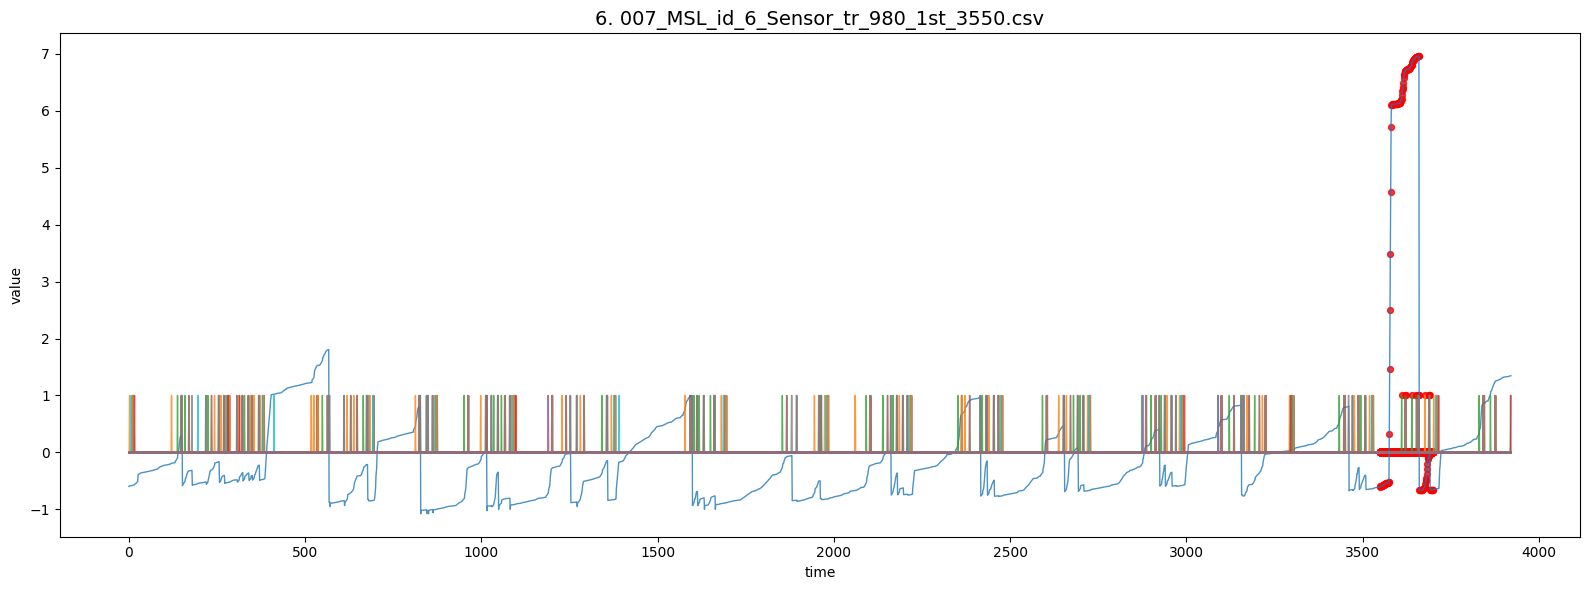


Нумерация файлов:
  1: 001_Genesis_id_1_Sensor_tr_4055_1st_15538.csv
  2: 002_MSL_id_1_Sensor_tr_500_1st_900.csv
  3: 003_MSL_id_2_Sensor_tr_883_1st_1238.csv
  4: 004_MSL_id_3_Sensor_tr_530_1st_630.csv
  5: 005_MSL_id_4_Sensor_tr_855_1st_2700.csv
  6: 006_MSL_id_5_Sensor_tr_1150_1st_1250.csv
  7: 007_MSL_id_6_Sensor_tr_980_1st_3550.csv
  8: 008_MSL_id_7_Sensor_tr_656_1st_1630.csv
  9: 009_MSL_id_8_Sensor_tr_714_1st_1390.csv
 10: 010_MSL_id_9_Sensor_tr_554_1st_1172.csv
 11: 011_MSL_id_10_Sensor_tr_1525_1st_4590.csv
 12: 012_MSL_id_11_Sensor_tr_539_1st_940.csv
 13: 013_MSL_id_12_Sensor_tr_554_1st_1200.csv
 14: 014_MSL_id_13_Sensor_tr_1525_1st_4575.csv
 15: 015_MSL_id_14_Sensor_tr_575_1st_1250.csv
 16: 016_MSL_id_15_Sensor_tr_500_1st_780.csv
 17: 017_MSL_id_16_Sensor_tr_512_1st_1850.csv
 18: 018_Daphnet_id_1_HumanActivity_tr_9693_1st_20732.csv
 19: 019_MITDB_id_1_Medical_tr_37500_1st_103211.csv
 20: 020_MITDB_id_2_Medical_tr_50000_1st_52315.csv
 21: 021_MITDB_id_3_Medical_tr_50000_1st_57

In [24]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ===== настройки =====
data_dir = Path("Datasets/TSB-AD-M")
files = sorted(data_dir.glob("*"))

selection = "1,2,4-7"   # какие файлы рисовать

# ===== парсер диапазонов =====
def parse_selection(selection_str):
    ids = set()
    for part in selection_str.split(","):
        part = part.strip()
        if "-" in part:
            a, b = part.split("-")
            ids.update(range(int(a), int(b) + 1))
        else:
            ids.add(int(part))
    return sorted(ids)

# ===== выбранные файлы =====
selected_ids = parse_selection(selection)
selected_files = [files[i - 1] for i in selected_ids if 1 <= i <= len(files)]

# ===== рисование =====
for idx, file_path in enumerate(selected_files, 1):
    df = pd.read_csv(file_path)

    feature_cols = df.columns[:-1]   # все кроме label
    label_col = df.columns[-1]

    anomaly_idx = df.index[df[label_col] == 1]

    plt.figure(figsize=(16, 6))

    for col in feature_cols:
        y = df[col]

        # линия ряда
        plt.plot(df.index, y, linewidth=1, alpha=0.8)

        # красные точки в местах аномалий
        plt.scatter(
            anomaly_idx,
            y.loc[anomaly_idx],
            color="red",
            s=18,
            alpha=0.8
        )

    plt.title(f"{idx}. {file_path.name}", fontsize=14)
    plt.xlabel("time")
    plt.ylabel("value")
    plt.tight_layout()
    plt.show()

# ===== список файлов =====
print("\nНумерация файлов:")
for i, f in enumerate(files, 1):
    print(f"{i:3d}: {f.name}")

In [26]:
# pip install jupyter-dash dash pandas plotly

from pathlib import Path
import pandas as pd
from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go

# ===============================
# ПАПКА С ФАЙЛАМИ
# ===============================
DATA_DIR = Path("Datasets/TSB-AD-M")

files = sorted(DATA_DIR.glob("*"))
file_dict = {f.name: f for f in files}

# ===============================
# APP
# ===============================
app = Dash(__name__)

app.layout = html.Div([
    
    html.H2("Multivariate Time Series Dashboard"),

    html.Div([
        html.Label("Файл:"),
        dcc.Dropdown(
            id="file_dropdown",
            options=[{"label": f.name, "value": f.name} for f in files],
            value=files[0].name if files else None,
            style={"width": "700px"}
        )
    ]),

    html.Br(),

    html.Div([
        html.Label("Выбрать ряды:"),
        dcc.Checklist(
            id="series_checklist",
            inline=False
        )
    ]),

    html.Br(),

    html.Div([
        html.Div([
            html.Label("X min"),
            dcc.Input(id="xmin", type="number")
        ]),
        html.Div([
            html.Label("X max"),
            dcc.Input(id="xmax", type="number")
        ]),
        html.Div([
            html.Label("Y min"),
            dcc.Input(id="ymin", type="number")
        ]),
        html.Div([
            html.Label("Y max"),
            dcc.Input(id="ymax", type="number")
        ]),
    ], style={
        "display": "grid",
        "gridTemplateColumns": "repeat(4, 180px)",
        "gap": "20px"
    }),

    html.Br(),

    dcc.Graph(
        id="graph",
        style={"height": "800px"}
    )
])

# ===============================
# обновить список рядов
# ===============================
@app.callback(
    Output("series_checklist", "options"),
    Output("series_checklist", "value"),
    Input("file_dropdown", "value")
)
def update_series(file_name):
    df = pd.read_csv(file_dict[file_name])

    cols = list(df.columns[:-1])  # последний label
    options = [{"label": c, "value": c} for c in cols]

    return options, cols


# ===============================
# график
# ===============================
@app.callback(
    Output("graph", "figure"),
    Input("file_dropdown", "value"),
    Input("series_checklist", "value"),
    Input("xmin", "value"),
    Input("xmax", "value"),
    Input("ymin", "value"),
    Input("ymax", "value"),
)
def update_graph(file_name, selected_cols, xmin, xmax, ymin, ymax):

    df = pd.read_csv(file_dict[file_name])

    label_col = df.columns[-1]
    anomaly_idx = df.index[df[label_col] == 1]

    fig = go.Figure()

    if selected_cols is None:
        selected_cols = []

    for col in selected_cols:

        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df[col],
                mode="lines",
                name=col
            )
        )

        # аномальные точки
        fig.add_trace(
            go.Scatter(
                x=anomaly_idx,
                y=df.loc[anomaly_idx, col],
                mode="markers",
                marker=dict(color="red", size=6),
                showlegend=False,
                hoverinfo="skip"
            )
        )

    fig.update_layout(
        title=file_name,
        template="plotly_white",
        hovermode="x unified"
    )

    # X limits
    if xmin is not None or xmax is not None:
        fig.update_xaxes(range=[
            xmin if xmin is not None else 0,
            xmax if xmax is not None else len(df)-1
        ])

    # Y limits
    if ymin is not None or ymax is not None:
        fig.update_yaxes(range=[
            ymin if ymin is not None else None,
            ymax if ymax is not None else None
        ])

    return fig


# ===============================
# RUN
# ===============================
app.run(debug=True, port=8050)

ModuleNotFoundError: No module named 'dash'

In [27]:
! pip install dash

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai